In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

%matplotlib inline
sns.set_style("whitegrid")

In [11]:
df_ch1 = pd.read_csv('embeddings/chinese1.csv')
df_ch2 = pd.read_csv('embeddings/chinese2.csv')

df_ko1 = pd.read_csv('embeddings/korean1.csv')
df_ko2 = pd.read_csv('embeddings/korean2.csv')

df_hi1 = pd.read_csv('embeddings/hindi1.csv')
df_hi2 = pd.read_csv('embeddings/hindi2.csv')

df_sp1 = pd.read_csv('embeddings/spanish1.csv')
df_sp2 = pd.read_csv('embeddings/spanish2.csv')

df_vi1 = pd.read_csv('embeddings/vietnamese1.csv')
df_vi2 = pd.read_csv('embeddings/vietnamese2.csv')

In [18]:
df_all = pd.concat([df_ch1, df_ch2,df_ko1,df_ko2,df_hi1,df_hi2,df_sp1,df_sp2,df_vi1,df_vi2], axis=0)


In [19]:
df_all = df_all.drop(columns=['Unnamed: 0'])
df_all

,0,1,2,3,4,5,6,7,8,9,...,759,760,761,762,763,764,765,766,767,Y
0,-0.058235,-0.019258,-0.050706,-0.009674,0.010946,-0.018359,-0.012785,-0.004975,-0.022771,0.005906,...,0.013653,-0.019193,-0.008815,0.012599,-0.041882,0.005779,0.054572,-0.015428,0.009473,Chinese
1,-0.048863,-0.022276,-0.023190,-0.003739,0.010929,-0.004820,-0.022528,-0.027746,0.021197,0.008233,...,0.017853,-0.019630,-0.052884,-0.007089,-0.031260,-0.002085,0.061593,-0.003851,0.001588,Chinese
2,-0.035846,-0.011878,-0.025055,0.008716,0.030596,-0.008715,-0.013879,-0.037098,0.015420,0.015673,...,0.025375,-0.014769,-0.028497,0.004719,-0.002389,-0.018726,0.051970,-0.011696,0.008038,Chinese
3,-0.019400,-0.006949,-0.050160,0.012594,0.030423,0.014611,0.006797,0.002716,-0.019097,0.026495,...,0.039846,-0.002651,0.023736,0.000570,-0.025349,0.002536,0.053523,0.000156,0.000665,Chinese
4,-0.015441,-0.026935,-0.009407,0.027895,0.014000,-0.002068,-0.037645,-0.021726,0.002393,-0.000629,...,0.025492,-0.019285,-0.007513,-0.006763,-0.026776,-0.014187,0.059283,0.008168,-0.004456,Chinese
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1127,-0.041166,-0.024820,-0.014139,-0.002901,0.008903,0.023717,-0.021891,-0.032310,0.003812,-0.005848,...,0.033347,-0.000536,0.017131,0.028483,-0.042176,0.002195,0.056575,0.020475,-0.003289,Vietnamese
1128,-0.023993,-0.024653,-0.038734,-0.005940,0.001055,0.025937,-0.020265,-0.000097,-0.007919,-0.021356,...,0.014057,-0.017720,0.009693,0.027790,-0.027948,-0.017069,0.063319,0.061423,0.011696,Vietnamese
1129,-0.029006,-0.022844,-0.033149,0.003541,0.017561,0.009686,-0.017903,-0.015563,0.000713,-0.007092,...,0.019976,0.003622,0.002247,0.018524,-0.043481,0.010369,0.045410,-0.000755,-0.000201,Vietnamese
1130,-0.037502,-0.005402,-0.035002,0.013312,0.024377,0.012711,-0.022482,-0.023377,-0.017982,0.008590,...,0.013687,-0.005106,-0.018927,0.000822,-0.016548,0.000107,0.015107,0.005927,0.003598,Vietnamese


In [20]:
df_all.drop(columns=['Y'])

,0,1,2,3,4,5,6,7,8,9,...,758,759,760,761,762,763,764,765,766,767
0,-0.058235,-0.019258,-0.050706,-0.009674,0.010946,-0.018359,-0.012785,-0.004975,-0.022771,0.005906,...,0.016332,0.013653,-0.019193,-0.008815,0.012599,-0.041882,0.005779,0.054572,-0.015428,0.009473
1,-0.048863,-0.022276,-0.023190,-0.003739,0.010929,-0.004820,-0.022528,-0.027746,0.021197,0.008233,...,0.015084,0.017853,-0.019630,-0.052884,-0.007089,-0.031260,-0.002085,0.061593,-0.003851,0.001588
2,-0.035846,-0.011878,-0.025055,0.008716,0.030596,-0.008715,-0.013879,-0.037098,0.015420,0.015673,...,0.001716,0.025375,-0.014769,-0.028497,0.004719,-0.002389,-0.018726,0.051970,-0.011696,0.008038
3,-0.019400,-0.006949,-0.050160,0.012594,0.030423,0.014611,0.006797,0.002716,-0.019097,0.026495,...,0.021066,0.039846,-0.002651,0.023736,0.000570,-0.025349,0.002536,0.053523,0.000156,0.000665
4,-0.015441,-0.026935,-0.009407,0.027895,0.014000,-0.002068,-0.037645,-0.021726,0.002393,-0.000629,...,0.004298,0.025492,-0.019285,-0.007513,-0.006763,-0.026776,-0.014187,0.059283,0.008168,-0.004456
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1127,-0.041166,-0.024820,-0.014139,-0.002901,0.008903,0.023717,-0.021891,-0.032310,0.003812,-0.005848,...,0.002069,0.033347,-0.000536,0.017131,0.028483,-0.042176,0.002195,0.056575,0.020475,-0.003289
1128,-0.023993,-0.024653,-0.038734,-0.005940,0.001055,0.025937,-0.020265,-0.000097,-0.007919,-0.021356,...,0.017682,0.014057,-0.017720,0.009693,0.027790,-0.027948,-0.017069,0.063319,0.061423,0.011696
1129,-0.029006,-0.022844,-0.033149,0.003541,0.017561,0.009686,-0.017903,-0.015563,0.000713,-0.007092,...,0.003880,0.019976,0.003622,0.002247,0.018524,-0.043481,0.010369,0.045410,-0.000755,-0.000201
1130,-0.037502,-0.005402,-0.035002,0.013312,0.024377,0.012711,-0.022482,-0.023377,-0.017982,0.008590,...,0.017524,0.013687,-0.005106,-0.018927,0.000822,-0.016548,0.000107,0.015107,0.005927,0.003598


In [21]:
df_all['Y']

0          Chinese
1          Chinese
2          Chinese
3          Chinese
4          Chinese
           ...    
1127    Vietnamese
1128    Vietnamese
1129    Vietnamese
1130    Vietnamese
1131    Vietnamese
Name: Y, Length: 11314, dtype: object

In [24]:

#unique_labels, counts = np.unique(np_labels, return_counts=True)
#valid_labels = unique_labels[counts >= 2]
#mask = np.isin(np_labels, valid_labels)

X_filtered = df_all.drop(columns=['Y'])
y_filtered = df_all['Y']

le = LabelEncoder()
y_encoded = le.fit_transform(y_filtered)

X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, 
    y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

In [25]:
params = {
    'objective': 'multi:softprob',
    'num_class': len(le.classes_), 
    'max_depth': 4,
    'learning_rate': 0.1,
    'n_estimators': 100,
    'alpha': 10,
    'random_state': 42
}

model = XGBClassifier(**params)
model.fit(X_train, y_train)
y_pred_numeric = model.predict(X_test)

y_pred_languages = le.inverse_transform(y_pred_numeric)
y_test_languages = le.inverse_transform(y_test)

In [26]:
print("\nAccuracy Score:", accuracy_score(y_test, y_pred_numeric))


Accuracy Score: 0.9359257622624835


In [27]:
print("\nClassification Report:")
print(classification_report(y_test_languages, y_pred_languages))


Classification Report:
              precision    recall  f1-score   support

     Chinese       0.94      0.92      0.93       452
       Hindi       0.96      0.96      0.96       453
      Korean       0.94      0.93      0.93       452
     Spanish       0.93      0.92      0.92       453
  Vietnamese       0.92      0.95      0.93       453

    accuracy                           0.94      2263
   macro avg       0.94      0.94      0.94      2263
weighted avg       0.94      0.94      0.94      2263



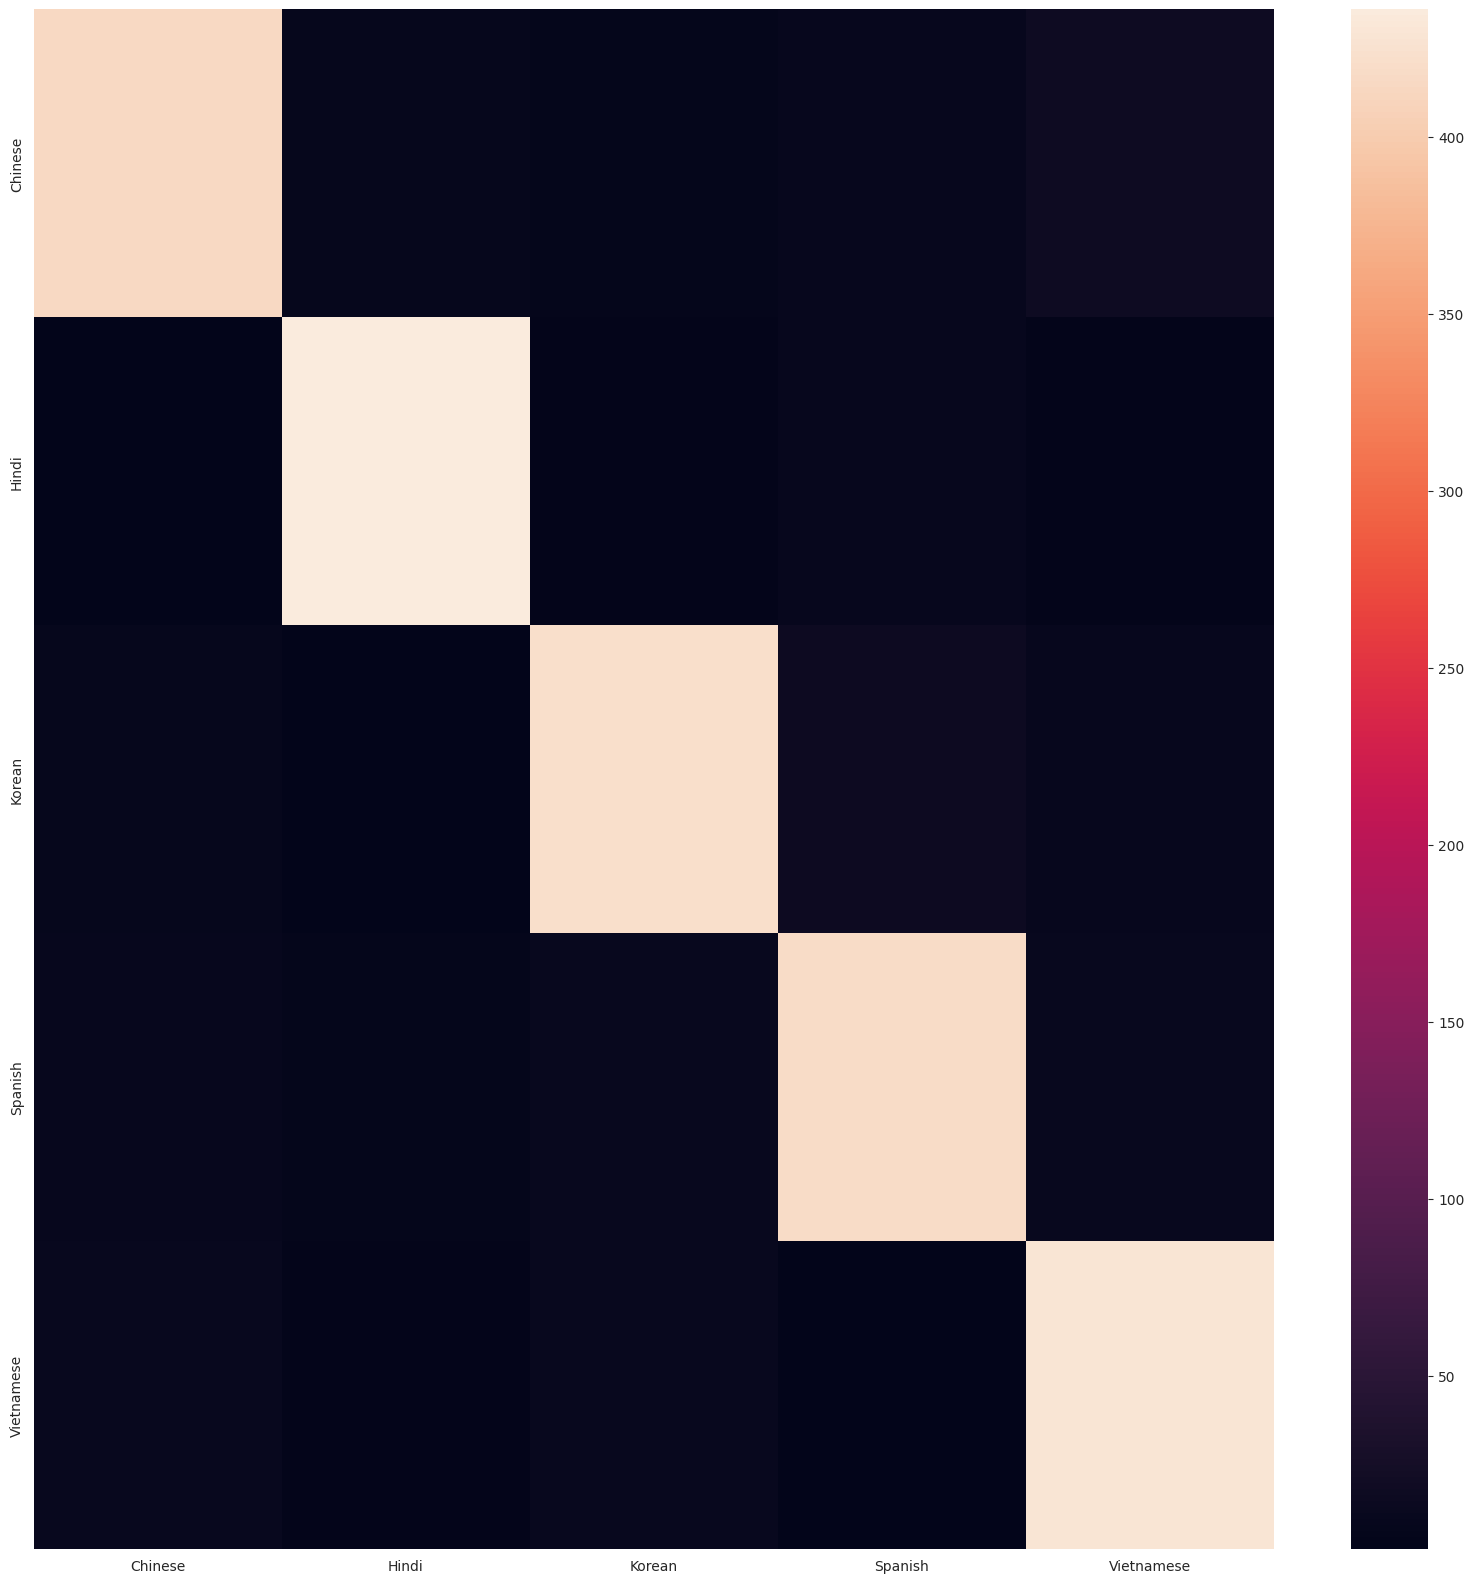

In [28]:
plt.figure(figsize=(20, 20))
cm = confusion_matrix(y_test_languages, y_pred_languages)
sns.heatmap(cm, annot=False, xticklabels=le.classes_, yticklabels=le.classes_)
plt.show()